**Generative AI Use**: For the purposes of the assignments, the use of generative AI is subject to the same policies regarding collaboration. Just as with other collaborators, each student must write down the solutions independently of the output of the interaction and the submission should include a note denoting the nature of the collaboration. The use of generative AI tools to substantially complete sections of the assignments is not in line with the spirit of the assignments, and would be a violation of the [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

**Student Declaration (must be completed)**

**SUNet id:**  
_Your SUNet id_

**Did you use generative AI tools (e.g., ChatGPT, Copilot, etc.)?**  
- [ ] No  
- [ ] Yes (please describe below)

**If yes, describe how you used generative AI and for what parts of the assignment :**  
_Your Answer_

**Confirm that all submitted work reflects your own understanding and that you did not rely on AI to complete substantial portions of the assignment:**  
- [ ] I confirm

In [1]:
# Local VS Code Setup (replaces Google Colab mount)
# This cell sets up the environment to run locally

import os
import sys

# Get the directory where this notebook is located
NOTEBOOK_DIR = os.getcwd()

# Add the assignment directory to Python path if not already there
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Python version: {sys.version}")

# Verify the cs231n module is accessible
assert os.path.exists("cs231n"), "cs231n folder not found. Make sure you are in the assignment3 directory."
print("Setup complete! cs231n module is accessible.")

# Download the COCO dataset if it does not exist
coco_path = os.path.join("cs231n", "datasets", "coco_captioning")
if not os.path.exists(coco_path):
    print("COCO dataset not found. Downloading...")
    import urllib.request
    import zipfile
    
    zip_path = os.path.join("cs231n", "datasets", "coco_captioning.zip")
    url = "http://cs231n.stanford.edu/coco_captioning.zip"
    
    # Ensure datasets directory exists
    os.makedirs(os.path.join("cs231n", "datasets"), exist_ok=True)
    
    # Download
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete. Unzipping...")
    
    # Extract
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.join("cs231n", "datasets"))
        
    # Clean up
    os.remove(zip_path)
    print("COCO dataset downloaded and extracted successfully!")
else:
    print("COCO dataset already exists.")

Working directory: c:\keyLabLocal_D\cs231n\assignments\assignment3
Python version: 3.10.10 (tags/v3.10.10:aad5f6a, Feb  7 2023, 17:20:36) [MSC v.1929 64 bit (AMD64)]
Setup complete! cs231n module is accessible.
COCO dataset already exists.


# Image Captioning with Transformers
You have now implemented a vanilla RNN and for the task of image captioning. In this notebook you will implement key pieces of a transformer decoder to accomplish the same task.

**NOTE:** This notebook will be primarily written in PyTorch rather than NumPy, unlike the RNN notebook.

In [2]:
# Setup cell.
import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import sys
import types
import importlib

from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.transformer_layers import *
from cs231n.captioning_solver_transformer import CaptioningSolverTransformer
from cs231n.classifiers.transformer import CaptioningTransformer
from cs231n.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from cs231n.image_utils import image_from_url

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # Set default size of plots.
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

# COCO Dataset
As in the previous notebooks, we will use the COCO dataset for captioning.

In [3]:
# Load COCO data from disk into a dictionary.
data = load_coco_data(pca_features=True)

# Print out all the keys and values from the data dictionary.
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

base dir  C:\keyLabLocal_D\cs231n\assignments\assignment3\cs231n\datasets/coco_captioning
train_captions <class 'numpy.ndarray'> (400135, 17) int32
train_image_idxs <class 'numpy.ndarray'> (400135,) int32
val_captions <class 'numpy.ndarray'> (195954, 17) int32
val_image_idxs <class 'numpy.ndarray'> (195954,) int32
train_features <class 'numpy.ndarray'> (82783, 512) float32
val_features <class 'numpy.ndarray'> (40504, 512) float32
idx_to_word <class 'list'> 1004
word_to_idx <class 'dict'> 1004
train_urls <class 'numpy.ndarray'> (82783,) <U63
val_urls <class 'numpy.ndarray'> (40504,) <U63


# Transformer
As you have seen, RNNs are incredibly powerful but often slow to train. Further, RNNs struggle to encode long-range dependencies (though LSTMs are one way of mitigating the issue). In 2017, Vaswani et al introduced the Transformer in their paper ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) to a) introduce parallelism and b) allow models to learn long-range dependencies. The paper not only led to famous models like BERT and GPT in the natural language processing community, but also an explosion of interest across fields, including vision. While here we introduce the model in the context of image captioning, the idea of attention itself is much more general.



# Transformer: Multi-Headed Attention

### Dot-Product Attention

Recall that attention can be viewed as an operation on a query $q\in\mathbb{R}^{d*E}$ (same correction below), a set of value vectors $\{v_1,\dots,v_n\}, v_i\in\mathbb{R}^d$, and a set of key vectors $\{k_1,\dots,k_n\}, k_i \in \mathbb{R}^d$, specified as

\begin{align}
c &= \sum_{i=1}^{n} v_i \alpha_i \\
\alpha_i &= \frac{\exp(k_i^\top q)}{\sum_{j=1}^{n} \exp(k_j^\top q)} \\
\end{align}

where $\alpha_i$ are frequently called the "attention weights", and the output $c\in\mathbb{R}^d$ is a correspondingly weighted average over the value vectors.

### Self-Attention
In Transformers, we perform self-attention, which means that the values, keys and query are derived from the input $X \in \mathbb{R}^{\ell \times d}$, where $\ell$ is our sequence length. Specifically, we learn parameter matrices $V,K,Q \in \mathbb{R}^{d\times d}$ to map our input $X$ as follows:

\begin{align}
v_i = Vx_i\ \ i \in \{1,\dots,\ell\}\\
k_i = Kx_i\ \ i \in \{1,\dots,\ell\}\\
q_i = Qx_i\ \ i \in \{1,\dots,\ell\}
\end{align}

### Multi-Headed Scaled Dot-Product Attention
In the case of multi-headed attention, we learn a parameter matrix for each head, which gives the model more expressivity to attend to different parts of the input. Let $h$ be number of heads, and $Y_i$ be the attention output of head $i$. Thus we learn individual matrices $Q_i$, $K_i$ and $V_i$. To keep our overall computation the same as the single-headed case, we choose $Q_i \in \mathbb{R}^{d\times d/h}$, $K_i \in \mathbb{R}^{d\times d/h}$ and $V_i \in \mathbb{R}^{d\times d/h}$. Adding in a scaling term $\frac{1}{\sqrt{d/h}}$ to our simple dot-product attention above, we have

<!-- \begin{equation} \label{qkv_eqn}
Y_i = \text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)(XV_i)
\end{equation} -->

$$
Y_i = \text{softmax}\left(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\right)(XV_i)
$$

where $Y_i\in\mathbb{R}^{\ell \times d/h}$, where $\ell$ is our sequence length.

In our implementation, we apply dropout to the attention weights (though in practice it could be used at any step):

<!-- \begin{equation} \label{qkvdropout_eqn} -->
$$
Y_i = \text{dropout}\bigg(\text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)\bigg)(XV_i)
$$
<!-- \end{equation} -->

Finally, then the output of the self-attention is a linear transformation of the concatenation of the heads:

\begin{equation}
Y = [Y_1;\dots;Y_h]A
\end{equation}

were $A \in\mathbb{R}^{d\times d}$ and $[Y_1;\dots;Y_h]\in\mathbb{R}^{\ell \times d}$.

Implement multi-headed scaled dot-product attention in the `MultiHeadAttention` class in the file `cs231n/transformer_layers.py`. The code below will check your implementation. The relative error should be less than `7e-3`.

In [4]:
torch.manual_seed(231)

# Choose dimensions such that they are all unique for easier debugging:
# Specifically, the following values correspond to N=1, H=2, T=3, E//H=4, and E=8.
batch_size = 1
sequence_length = 3
embed_dim = 8
attn = MultiHeadAttention(embed_dim, num_heads=2)
attn.eval()

# Self-attention.
data = torch.randn(batch_size, sequence_length, embed_dim)
self_attn_output = attn(query=data, key=data, value=data)

# Masked self-attention.
mask = torch.randn(sequence_length, sequence_length) < 0.5
masked_self_attn_output = attn(query=data, key=data, value=data, attn_mask=mask)

# Attention using two inputs.
other_data = torch.randn(batch_size, sequence_length, embed_dim)
attn_output = attn(query=data, key=other_data, value=other_data)

expected_self_attn_output = np.asarray([[
    [-0.1030,  0.2090,  0.7481, -0.4116, -0.2772,  0.2357, -0.2740, -0.2798],
    [-0.1794,  0.1637,  0.6930, -0.3435, -0.2300,  0.2457, -0.2504, -0.2323],
    [-0.1861,  0.1567,  0.6677, -0.3078, -0.2731,  0.2302, -0.2714, -0.2082]]])

expected_masked_self_attn_output = np.asarray([[
    [-0.1209,  0.1806,  0.8056, -0.4654, -0.2262,  0.2552, -0.2544, -0.2812],
    [-0.2374,  0.1183,  0.7423, -0.3777, -0.1460,  0.2716, -0.2213, -0.2077],
    [-0.0851,  0.2423,  0.7941, -0.3778, -0.4924,  0.1512, -0.4241, -0.1740]]])

expected_attn_output = np.asarray([[
    [-0.1965,  0.0702,  0.5227, -0.1388, -0.3530,  0.2163, -0.2643, -0.1902],
    [-0.3592, -0.0899,  0.5836,  0.0029, -0.3643,  0.2667, -0.1973, -0.1698],
    [-0.3795,  0.0433,  0.5634, -0.0749, -0.4379,  0.2714, -0.2207, -0.1980]]])

print('self_attn_output error: ', rel_error(expected_self_attn_output, self_attn_output.detach().numpy()))
print('masked_self_attn_output error: ', rel_error(expected_masked_self_attn_output, masked_self_attn_output.detach().numpy()))
print('attn_output error: ', rel_error(expected_attn_output, attn_output.detach().numpy()))

self_attn_output error:  0.0001792071437561575
masked_self_attn_output error:  9.809519326315612e-05
attn_output error:  0.006226898176165351


# Positional Encoding

While transformers are able to easily attend to any part of their input, the attention mechanism has no concept of token order. However, for many tasks (especially natural language processing), relative token order is very important. To recover this, the authors add a positional encoding to the embeddings of individual word tokens.

Let us define a matrix $P \in \mathbb{R}^{l\times d}$, where $P_{ij} = $

$$
\begin{cases}
\text{sin}\left(i \cdot 10000^{-\frac{j}{d}}\right) & \text{if j is even} \\
\text{cos}\left(i \cdot 10000^{-\frac{(j-1)}{d}}\right) & \text{otherwise} \\
\end{cases}
$$

Rather than directly passing an input $X \in \mathbb{R}^{l\times d}$ to our network, we instead pass $X + P$.

Implement this layer in `PositionalEncoding` in `cs231n/transformer_layers.py`. Once you are done, run the following to perform a simple test of your implementation. You should see errors on the order of `e-3` or less.

<br>
<br>
<br>

my understanding of: why X=X+P,this way, it can add the position info to the source feature?



Edited transformer_layers.py
Viewed transformer_layers.py:68-112

The reason element-wise addition **$X + P$** successfully injects positional information without destroying the original token features comes down to **high-dimensional geometry** and the **linearity of matrix multiplication**.

---

### 1. The Core Problem: Attention is Order-Agnostic
Standard self-attention computes dot products between queries and keys ($\text{Softmax}(Q K^T) V$). 

If you shuffle the input words in a sentence, the attention output is identical (just shuffled). Self-attention has **no built-in concept of word order** (it treats sequence positions like an unordered set). Therefore, position information must be explicitly added to each token vector $x_i$.

---

### 2. Intuition: Shifting Points in Vector Space
Think of a word embedding $x_i \in \mathbb{R}^D$ as a point in a $D$-dimensional semantic space (e.g., $D=512$):

- $x_i$ represents **semantic content** (e.g., the word *"cat"*).
- $p_i$ is a position-specific **displacement vector** for position $i$.

When you compute $x_i + p_i$:
- You shift the word vector $x_i$ slightly in space by $p_i$.
- Because high-dimensional space ($D=512$) is extremely vast and sparse, adding $p_i$ does **not** "destroy" or "overwrite" the word's meaning. It simply "tags" the word vector with its position.

---

### 3. Mathematical Proof: Linear Projection ($W$)
When the sum $x_i + p_i$ passes into a linear layer (like Query, Key, or Value projection matrices $W_Q, W_K, W_V$), **matrix multiplication is linear**:

$$W(x_i + p_i) = W x_i + W p_i$$

This means the linear layer can process **both** the semantic feature ($W x_i$) and the positional feature ($W p_i$) simultaneously!

---

### 4. What Happens in Attention Dot Products?
When computing the attention score between token $i$ and token $j$:

$$Q_i K_j^T = (x_i + p_i) W_Q W_K^T (x_j + p_j)^T$$

Expanding this product gives **4 distinct interactions**:

$$Q_i K_j^T = \underbrace{x_i W_Q W_K^T x_j^T}_{\mathbf{1.\ Content \text{--} Content}} + \underbrace{x_i W_Q W_K^T p_j^T}_{\mathbf{2.\ Content \text{--} Position}} + \underbrace{p_i W_Q W_K^T x_j^T}_{\mathbf{3.\ Position \text{--} Content}} + \underbrace{p_i W_Q W_K^T p_j^T}_{\mathbf{4.\ Position \text{--} Position}}$$

Through gradient descent, the model learns to balance:
1. How word meanings relate to each other ($x_i \leftrightarrow x_j$).
2. How relative distance/positions relate to each other ($p_i \leftrightarrow p_j$).

---

### 5. Why Addition Instead of Concatenation $[x_i \,;\, p_i]$?

| Technique | Dimensionality | Compute & Memory Cost |
| :--- | :--- | :--- |
| **Concatenation** $[x_i ; p_i]$ | Larger dimension $(D + D_{pos})$ | Increases weight matrix sizes and memory in **every single layer** of the Transformer. |
| **Addition** $x_i + p_i$ | Keeps dimension $D$ unchanged | Zero extra memory or parameter overhead across all subsequent layers. |

Because high-dimensional spaces can easily hold semantic and positional information in the same $D$-dimensional vector, **addition $X + P$ is both mathematically sound and computationally efficient.**

Here is a concrete numerical demonstration using a **10-dimensional embedding space** ($D = 10$).

---

### Step 1: The Word Embedding for `"cat"` ($x_{\text{cat}}$)
The word embedding for `"cat"` is a fixed 10D vector representing its semantic meaning (furry, animal, pet, etc.). It remains **identical** regardless of where `"cat"` appears in a sentence:

$$x_{\text{cat}} = \big[\, 0.80,\ -0.50,\ \ 1.20,\ \ 0.10,\ -0.90,\ \ 0.40,\ \ 0.70,\ -0.30,\ \ 0.00,\ \ 1.10 \,\big]$$

---

### Step 2: The Positional Encoding Vectors ($p_{\text{pos}}$)
Using the Transformer's sinusoidal formula ($\sin$ and $\cos$ waves of varying frequencies across dimensions), each position $1, 2, 5, 10$ gets a unique, deterministic 10D positional pattern:

$$\begin{aligned}
p_{1}  &= \big[\, \ \ 0.84,\ \ 0.54,\ \ 0.16,\ \ 0.99,\ \ 0.03,\ \ 1.00,\ \ 0.00,\ \ 1.00,\ \ 0.00,\ \ 1.00 \,\big] \\
p_{2}  &= \big[\, \ \ 0.91,\ -0.42,\ \ 0.31,\ \ 0.95,\ \ 0.05,\ \ 1.00,\ \ 0.01,\ \ 1.00,\ \ 0.00,\ \ 1.00 \,\big] \\
p_{5}  &= \big[\, -0.96,\ \ 0.28,\ \ 0.71,\ \ 0.70,\ \ 0.13,\ \ 0.99,\ \ 0.02,\ \ 1.00,\ \ 0.00,\ \ 1.00 \,\big] \\
p_{10} &= \big[\, -0.54,\ -0.84,\ \ 1.00,\ -0.01,\ \ 0.25,\ \ 0.97,\ \ 0.04,\ \ 1.00,\ \ 0.01,\ \ 1.00 \,\big]
\end{aligned}$$

---

### Step 3: What the Model Receives ($x_{\text{cat}} + p_{\text{pos}}$)

When we perform element-wise addition $X + P$, we combine semantic meaning with position:

#### 1. `"Cat"` at Position 1 (e.g., *"Cat is on the mat."*)
$$\begin{array}{rccccccccccc}
x_{\text{cat}} : & [ & 0.80, & -0.50, & 1.20, & 0.10, & -0.90, & 0.40, & 0.70, & -0.30, & 0.00, & 1.10 & ] \\
+\ p_{1} : & [ & 0.84, & 0.54, & 0.16, & 0.99, & 0.03, & 1.00, & 0.00, & 1.00, & 0.00, & 1.00 & ] \\
\hline
\mathbf{Input_1} : & \mathbf{[} & \mathbf{1.64,} & \mathbf{0.04,} & \mathbf{1.36,} & \mathbf{1.09,} & \mathbf{-0.87,} & \mathbf{1.40,} & \mathbf{0.70,} & \mathbf{0.70,} & \mathbf{0.00,} & \mathbf{2.10} & \mathbf{]}
\end{array}$$

#### 2. `"Cat"` at Position 2 (e.g., *"The cat sat..."*)
$$\begin{array}{rccccccccccc}
x_{\text{cat}} : & [ & 0.80, & -0.50, & 1.20, & 0.10, & -0.90, & 0.40, & 0.70, & -0.30, & 0.00, & 1.10 & ] \\
+\ p_{2} : & [ & 0.91, & -0.42, & 0.31, & 0.95, & 0.05, & 1.00, & 0.01, & 1.00, & 0.00, & 1.00 & ] \\
\hline
\mathbf{Input_2} : & \mathbf{[} & \mathbf{1.71,} & \mathbf{-0.92,} & \mathbf{1.51,} & \mathbf{1.05,} & \mathbf{-0.85,} & \mathbf{1.40,} & \mathbf{0.71,} & \mathbf{0.70,} & \mathbf{0.00,} & \mathbf{2.10} & \mathbf{]}
\end{array}$$

#### 3. `"Cat"` at Position 5 (e.g., *"I saw a cute cat..."*)
$$\begin{array}{rccccccccccc}
x_{\text{cat}} : & [ & 0.80, & -0.50, & 1.20, & 0.10, & -0.90, & 0.40, & 0.70, & -0.30, & 0.00, & 1.10 & ] \\
+\ p_{5} : & [ & -0.96, & 0.28, & 0.71, & 0.70, & 0.13, & 0.99, & 0.02, & 1.00, & 0.00, & 1.00 & ] \\
\hline
\mathbf{Input_5} : & \mathbf{[} & \mathbf{-0.16,} & \mathbf{-0.22,} & \mathbf{1.91,} & \mathbf{0.80,} & \mathbf{-0.77,} & \mathbf{1.39,} & \mathbf{0.72,} & \mathbf{0.70,} & \mathbf{0.00,} & \mathbf{2.10} & \mathbf{]}
\end{array}$$

#### 4. `"Cat"` at Position 10 (e.g., *"Yesterday morning in the garden, I found a cat."*)
$$\begin{array}{rccccccccccc}
x_{\text{cat}} : & [ & 0.80, & -0.50, & 1.20, & 0.10, & -0.90, & 0.40, & 0.70, & -0.30, & 0.00, & 1.10 & ] \\
+\ p_{10} : & [ & -0.54, & -0.84, & 1.00, & -0.01, & 0.25, & 0.97, & 0.04, & 1.00, & 0.01, & 1.00 & ] \\
\hline
\mathbf{Input_{10}} : & \mathbf{[} & \mathbf{0.26,} & \mathbf{-1.34,} & \mathbf{2.20,} & \mathbf{0.09,} & \mathbf{-0.65,} & \mathbf{1.37,} & \mathbf{0.74,} & \mathbf{0.70,} & \mathbf{0.01,} & \mathbf{2.10} & \mathbf{]}
\end{array}$$

---

### What to Notice in the Numbers:

1. **"Cat" features are preserved**:
   - Look at dimensions 6 to 9 (e.g., `0.70, 0.70, 0.00, 2.10`). They remain nearly constant across all 4 positions because high-index dimensions oscillate very slowly. This retains the core semantic identity of `"cat"`.

2. **Position features fluctuate fast in early dimensions**:
   - Look at dimension 0 across positions 1, 2, 5, 10:
     - Pos 1: `1.64`
     - Pos 2: `1.71`
     - Pos 5: `-0.16`
     - Pos 10: `0.26`
   - Early dimensions vary rapidly according to position, acting like a high-frequency clock that tells the attention mechanism exactly where `"cat"` sits in the sentence!

In [5]:
torch.manual_seed(231)

batch_size = 1
sequence_length = 2
embed_dim = 6
data = torch.randn(batch_size, sequence_length, embed_dim)

pos_encoder = PositionalEncoding(embed_dim)
pos_encoder.eval()
output = pos_encoder(data)

expected_pe_output = np.asarray([[[-1.1106,  1.0014,  1.5280, -0.0778, -0.6964,  1.1455],
                                  [ 0.8125, -0.4303,  0.4981,  0.7320,  1.1380,  1.5331]]])
print('pe_output error: ', rel_error(expected_pe_output, output.detach().numpy()))

pe_output error:  0.00021699471301977143


# Inline Question 1

Several key design decisions were made in designing the scaled dot product attention we introduced above. Explain why the following choices were beneficial:
1. Using multiple attention heads as opposed to one.
2. Dividing by $\sqrt{d/h}$ before applying the softmax function. Recall that $d$ is the feature dimension and $h$ is the number of heads.
3. Adding a linear transformation to the output of the attention operation.

Only one or two sentences per choice is necessary, but be sure to be specific in addressing what would have happened without each given implementation detail, why such a situation would be suboptimal, and how the proposed implementation improves the situation.

**Your Answer:** 
1. multiple heads can attend to different modules of a sentence, such as content, grammar, semantic, etc.
2. when we do `E_score = q @ k_transpose / math.sqrt(D)`, the `D` is $\sqrt{d/h}$. Firstly, if `D = d` we do `/math.sqrt(D)` to normalize, balance the long dimension issue of dot product. 

because:

If we assume the elements inside vector $\mathbf{a}$ are roughly constant values of magnitude $a$, then the vector length $\Vert{}\mathbf{a}\Vert{}$ (or L2-norm) is calculated as:$$\Vert{}\mathbf{a}\Vert{} = \sqrt{\sum_{i=1}^{D_X} a^2} = \sqrt{D_X \cdot a^2} = a \sqrt{D_X}$$What this means: As the dimension $D_X$ gets larger (e.g., growing from $64$ to $512$ or $1024$), the length of the vectors automatically grows proportionally to $\sqrt{D_X}$.

Secondly, we devided by h, because the length of the dimension of input x, is devided, split to h heads. So, previouly, we devide $\sqrt{D_X}$ to keep the vector magnitude relatively the same. Now, we don't need to decrease the length that much. so we only devide by $\sqrt{D_X}/2$, eg when h = 2.

3. The split heads, need a linear layer to combine the different modules of a sentence, such as content, grammar, semantic, etc. back to the one sequence of output.



# Transformer Decoder Block

Transformer decoder layer consists of three modules: (1) self attention to process input sequence of vectors, (2) cross attention to process based on available context (i.e. image features in our case), (3) feedforward module to process each vector of the sequence independently. Complete the implementation of `TransformerDecoderLayer` in `cs231n/transformer_layers.py` and test it below. The relative error should be less than 1e-6.

The Transformer decoder layer has three main components: (1) a self-attention module that processes the input sequence of vectors, (2) a cross-attention module that incorporates additional context (e.g., image features in our case), and (3) a feedforward module that independently processes each vector in the sequence. Complete the implementation of `TransformerDecoderLayer` in `cs231n/transformer_layers.py` and test it below. The relative error should be less than 1e-6.

In [9]:
torch.manual_seed(231)
np.random.seed(231)

N, T, TM, D = 1, 4, 5, 12

decoder_layer = TransformerDecoderLayer(D, 2, 4*D)
decoder_layer.eval()
tgt = torch.randn(N, T, D)
memory = torch.randn(N, TM, D)
tgt_mask = torch.randn(T, T) < 0.5

output = decoder_layer(tgt, memory, tgt_mask)

expected_output = np.asarray([
    [[ 0.27005595, -0.21056601,  0.63376445, -0.35391954,  0.60071295,
      -1.7566615,  -0.1314159,  -1.7659538,  -0.5575517,   0.680143,
       1.8622686,   0.7291234],
     [-0.6080135,   0.4421802,  -0.07590749, -0.12093157,  0.94722354,
      -1.0223433,   0.47332686, -1.3958666,   2.1890075,  -1.0380646,
       0.9437816,  -0.7343922],
     [-0.89690155,  0.60447216,  0.10688882,  0.03492759,  1.8388084,
      -0.9772293,   0.7621334,  -0.668234,    1.3260399,  -1.8417019,
       0.21718435, -0.506388],
     [-0.70961505, -0.02918372, -0.39894593, -0.8069395,   0.04967685,
       0.29345992,  0.7871747,  -1.3172938,   1.4744806,   1.2633642,
       1.1611108,  -1.767289]]
])
print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  1.5224654802442538e-06


# Transformer for Image Captioning
Now that you have implemented the previous layers, you can combine them to build a Transformer-based image captioning model. Open the file `cs231n/classifiers/transformer.py` and look at the `CaptioningTransformer` class.

Implement the `forward` function of the class. After doing so, run the following to check your forward pass using a small test case; you should see error on the order of `e-5` or less.

In [12]:
torch.manual_seed(231)
np.random.seed(231)

N, D, W = 4, 20, 30
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
V = len(word_to_idx)
T = 3

transformer = CaptioningTransformer(
    word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    num_heads=2,
    num_layers=2,
    max_length=30
)
transformer.eval()

features = torch.randn(N, D)
captions = torch.randint(0, V, (N, T))

scores = transformer(features, captions)

expected_scores = np.asarray([
    [[ 0.62165695, -0.6203744,  -1.116114  ],
     [ 0.6641097,  -0.60309553, -1.3479083 ],
     [ 0.62117404, -0.79205745, -1.1095243 ]],
    [[ 0.62160987, -0.6214724,  -1.1171186 ],
     [ 0.6093992,  -0.61166143, -1.3365762 ],
     [ 0.62108713, -0.79322916, -1.1104958 ]],
    [[ 0.6406587,  -0.57419956, -1.1300566 ],
     [ 0.6075228,  -0.60872054, -1.3372457 ],
     [ 0.6471472,  -0.8270494,  -1.1064028 ]],
    [[ 0.64029807, -0.5755552,  -1.1284486 ],
     [ 0.60708034, -0.6099963,  -1.3356377 ],
     [ 0.59367496, -0.8346836,  -1.0914496 ]]
])

print('scores error: ', rel_error(expected_scores, scores.detach().numpy()))

scores error:  2.108501834260506e-07


Q: "features has shape (N, D).
self.visual_projection(features) projects it to shape (N, W).
You need to add a sequence dimension $S = 1$ using .unsqueeze(1) so memory has 3 dimensions: (N, 1, W).
python
features_proj = self.visual_projection(features).unsqueeze(1)  # Shape: (N, 1, W)", tell me more. I don't understand. 

A:

Viewed transformer_layers.py:306-349

Here is a detailed, intuitive breakdown of why we need `.unsqueeze(1)` and what is happening behind the scenes.

---

### 1. The Core Issue: 2D vs. 3D Tensors

Every layer in a Transformer model expects data as **3D Tensors**:

$$\text{Shape: } (\text{Batch Size } N,\ \text{Sequence Length } S,\ \text{Feature Dimension } W)$$

Let's compare your two inputs:

#### A. Caption Input (`captions`)
- A batch of $N = 4$ sentences.
- Each sentence has $T = 30$ words.
- Each word is embedded into $W = 256$ numbers.
- **Shape of `captions_embedding`**: **`(4, 30, 256)`**  *(3D Tensor)*  
  - $\text{Dim 0} = 4$ (Batch)
  - $\text{Dim 1} = 30$ (Sequence length $T$)
  - $\text{Dim 2} = 256$ (Feature size $W$)

---

#### B. Image Features Input (`features`)
- A batch of $N = 4$ images processed by a CNN.
- The CNN outputs **one feature vector per image** of size $D = 512$.
- **Initial shape of `features`**: **`(4, 512)`**  *(2D Tensor - Matrix)*

When you apply `self.visual_projection` (which is an `nn.Linear(512, 256)`):
```python
features_proj = self.visual_projection(features)
```
- It projects dimension $512 \to 256$.
- **Shape of `features_proj`**: **`(4, 256)`**  *(Still a 2D Tensor!)*

---

### 2. Why is `(4, 256)` a Problem for `TransformerDecoder`?

If you pass `features_proj` of shape `(4, 256)` into `TransformerDecoder` as `memory`, PyTorch will throw an error!

Why? Because the Transformer expects `memory` to have 3 dimensions:
- `memory` shape: `(N, S, W)` where $S$ is the **source sequence length**.

For a text-to-text model, $S$ would be the number of words in the input text (e.g., $S = 50$).  
For our image model, we have **1 image feature vector per image**, so **$S = 1$**.

However, a 2D tensor `(4, 256)` only has **2 dimensions**:
$$\big[\,\text{Batch}(N=4),\ \text{Embedding}(W=256)\,\big]$$

It is missing the middle **Sequence Length dimension ($S$)**!

---

### 3. What `.unsqueeze(1)` Does

In PyTorch, `.unsqueeze(dim)` inserts a new dimension of size **1** at index `dim`.

If `features_proj` has shape `(4, 256)` (indices 0 and 1):

```python
features_proj = features_proj.unsqueeze(1)
```

This inserts a dimension at index 1, transforming the shape from `(4, 256)` to **`(4, 1, 256)`**:

| Index | Meaning | Size |
| :--- | :--- | :--- |
| **Dim 0** | Batch size ($N$) | `4` |
| **Dim 1** | Source Sequence length ($S$) | **`1`** *(1 image vector per example)* |
| **Dim 2** | Feature dimension ($W$) | `256` |

Now `features_proj` is a valid 3D Tensor `(N, 1, W)`!

---

### 4. How Cross-Attention Uses This

Inside Cross-Attention, the Transformer compares:
- **Queries ($Q$)** from text: Shape `(4, 30, 256)` $\to$ 30 words per sentence.
- **Keys ($K$)** from image: Shape `(4, 1, 256)` $\to$ 1 image vector per image.

During matrix multiplication $Q \times K^T$:
$$\underbrace{(4, 30, 256)}_{Q} \times \underbrace{(4, 256, 1)}_{K^T} = \underbrace{(4, 30, 1)}_{\text{Attention Weights}}$$

Each of the 30 words in the sentence computes an attention score with that **1 image vector**! 

Without `.unsqueeze(1)`, PyTorch cannot perform this 3D matrix multiplication.

# Overfit Transformer Captioning Model on Small Data
Run the following to overfit the Transformer-based captioning model on the same small dataset as we used for the RNN previously.

base dir  C:\keyLabLocal_D\cs231n\assignments\assignment3\cs231n\datasets/coco_captioning
(Iteration 1 / 200) loss: 5.055427
(Iteration 11 / 200) loss: 2.819050
(Iteration 21 / 200) loss: 2.036877
(Iteration 31 / 200) loss: 1.659048
(Iteration 41 / 200) loss: 1.313489
(Iteration 51 / 200) loss: 1.195412
(Iteration 61 / 200) loss: 0.864514
(Iteration 71 / 200) loss: 0.806814
(Iteration 81 / 200) loss: 0.566810
(Iteration 91 / 200) loss: 0.435672
(Iteration 101 / 200) loss: 0.380263
(Iteration 111 / 200) loss: 0.157928
(Iteration 121 / 200) loss: 0.111748
(Iteration 131 / 200) loss: 0.102176
(Iteration 141 / 200) loss: 0.077055
(Iteration 151 / 200) loss: 0.072139
(Iteration 161 / 200) loss: 0.046707
(Iteration 171 / 200) loss: 0.039754
(Iteration 181 / 200) loss: 0.028434
(Iteration 191 / 200) loss: 0.027322


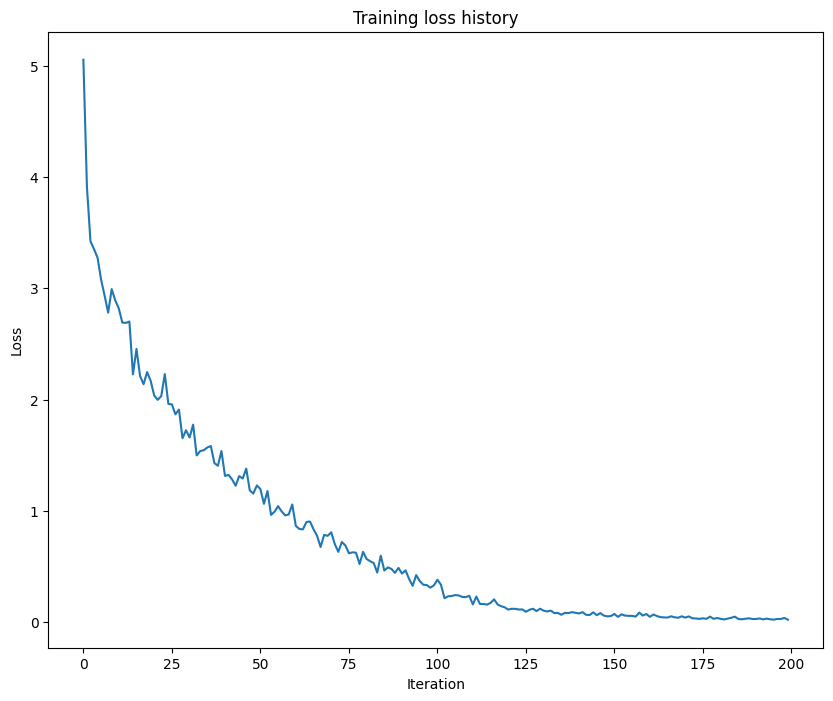

In [13]:
torch.manual_seed(231)
np.random.seed(231)

data = load_coco_data(max_train=50)

transformer = CaptioningTransformer(
          word_to_idx=data['word_to_idx'],
          input_dim=data['train_features'].shape[1],
          wordvec_dim=256,
          num_heads=2,
          num_layers=2,
          max_length=30
        )


transformer_solver = CaptioningSolverTransformer(transformer, data, idx_to_word=data['idx_to_word'],
           num_epochs=100,
           batch_size=25,
           learning_rate=0.001,
           verbose=True, print_every=10,
         )

transformer_solver.train()

# Plot the training losses.
plt.plot(transformer_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.show()

Print final training loss. You should see a final loss of less than 0.05 .

In [14]:
print('Final loss: ', transformer_solver.loss_history[-1])

Final loss:  0.020686457


# Transformer Sampling at Test Time
The sampling code has been written for you. You can simply run the following to compare with the previous results with the RNN. As before the training results should be much better than the validation set results, given how little data we trained on.

URL Error:  Not Found http://farm4.staticflickr.com/3355/3656962454_3e7f33dac3_z.jpg


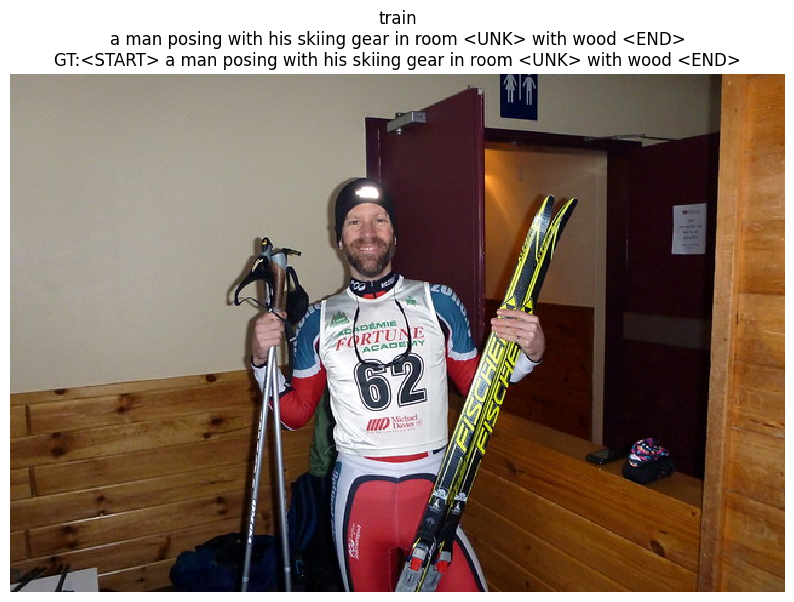

URL Error:  Not Found http://farm7.staticflickr.com/6038/6364580705_12de27ab54_z.jpg


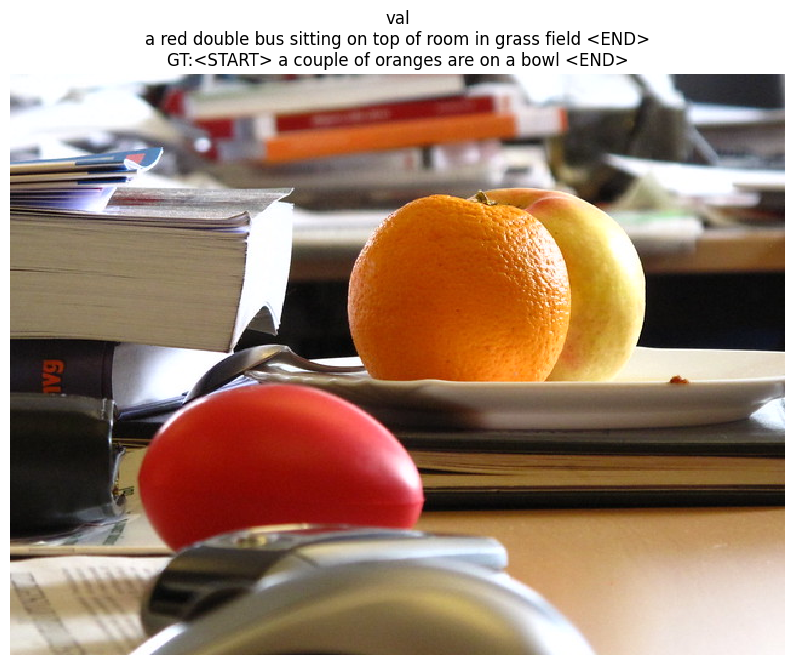

In [17]:
# If you get an error, the URL just no longer exists, so don't worry!
# You can re-sample as many times as you want.
for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = transformer.sample(features, max_length=30)
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # Skip missing URLs.
        if img is None: continue
        plt.imshow(img)
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()

# Vision Transformer (ViT)

[Dosovitskiy et. al.](https://arxiv.org/abs/2010.11929) showed that applying a transformer model on a sequence of image patches (referred to as Vision Transformer) not only achieves impressive performance but also scales more effectively than convolutional neural networks when trained on large datasets. We will build a version of Vision Transformer using our existing implementation of transformer components and train it on the CIFAR-10 dataset.

Vision Transformer converts input image into a sequence of patches of fixed size and embed each patch into a latent vector. In `cs231n/transformer_layers.py`, complete the implementation of `PatchEmbedding` and test it below. You should see relative error less than 1e-4.

In [23]:
from cs231n.transformer_layers import PatchEmbedding

torch.manual_seed(231)
np.random.seed(231)

N = 2
HW = 16
PS = 8
D = 8

patch_embedding = PatchEmbedding(
    img_size=HW,
    patch_size=PS,
    embed_dim=D
)

x = torch.randn(N, 3, HW, HW)
output = patch_embedding(x)

expected_output = np.asarray([
        [[-0.6312704 ,  0.02531429,  0.6112642 , -0.49089882,
          0.01412961, -0.6959372 , -0.32862484, -0.45402682],
        [ 0.18816411, -0.08142513, -0.9829535 , -0.23975623,
         -0.23109074,  0.97950286, -0.40997326,  0.7457837 ],
        [ 0.01810865,  0.15780598, -0.91804236,  0.36185235,
          0.8379501 ,  1.0191797 , -0.29667392,  0.20322265],
        [-0.18697818, -0.45137224, -0.40339014, -1.4381214 ,
         -0.43450755,  0.7651071 , -0.83683825, -0.16360264]],

       [[-0.39786366,  0.16201034, -0.19008337, -1.0602452 ,
         -0.28693503,  0.09791763,  0.26614824,  0.41781986],
        [ 0.35146567, -0.4469593 , -0.1841726 ,  0.45757473,
         -0.61304873, -0.29104248, -0.16124889, -0.14987172],
        [-0.2996967 ,  0.27353522, -0.09929767,  0.01973832,
         -1.2312065 , -0.6374332 , -0.22963578,  0.55696607],
        [-0.93818814,  0.02465284, -0.21117875,  1.1860403 ,
         -0.06137538, -0.21062079, -0.094347  ,  0.50032747]]])

print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  5.93853582728669e-06


The sequence of patch vectors is processed by transformer encoder layers, each consisting of a self-attention and a feed-forward module. Since all vectors attend to one another, attention masking is not strictly necessary. However, we still implement it for the sake of consistency.

Implement `TransformerEncoderLayer` in `cs231n/transformer_layers.py` and test it below. You should see relative error less than 1e-6.


In [24]:
torch.manual_seed(231)
np.random.seed(231)

from cs231n.transformer_layers import TransformerEncoderLayer

N, T, TM, D = 1, 4, 5, 12

encoder_layer = TransformerEncoderLayer(D, 2, 4*D)
encoder_layer.eval()
x = torch.randn(N, T, D)
x_mask = torch.randn(T, T) < 0.5

output = encoder_layer(x, x_mask)

expected_output = np.asarray([
    [[-0.48887438, -0.16470742,  0.7249629,  -1.0907345,   1.5764195,
       0.17484017,  0.8643941,  -0.5209561,  -1.6651545,  -1.1943513,
       1.4809005,   0.30326116],
     [-0.14663944,  1.052812,   -0.96227,    -0.20350897, -2.1478589,
       1.2637341,   0.04015125, -0.945255,    1.408903,   -0.43051198,
       0.37110543,  0.69933903],
     [ 0.08718029,  0.91050833, -1.208469,    1.1440394,  -1.9794976,
      -0.38342738, -0.47407156, -0.17345548,  0.11738186,  1.9534125,
       0.3525986,  -0.3461999],
     [-0.81389004,  0.76213264, -0.7094313,  -1.5332246,   1.3837544,
       0.4091982,   0.6569406,   0.7305365,  -1.197077,   -1.3698943,
       0.58292854,  1.0980265]]
])

print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  9.230481707432173e-07


Take a look at the `VisionTransformer` implementation in `cs231n/classifiers/transformer.py`.

For classification, ViT divides the input image into patches and processes the sequence of patch vectors using a transformer. Finally, all the patch vectors are average-pooled and used to predict the image class. We will use the same 1D sinusoidal positional encoding to inject ordering information, though 2D sinusoidal and learned positional encodings are also valid choices.

Complete the ViT forward pass and test it below. You should see relative error less than 1e-6.

In [26]:
torch.manual_seed(231)
np.random.seed(231)
from cs231n.classifiers.transformer import VisionTransformer

imgs = torch.randn(3, 3, 32, 32)
transformer = VisionTransformer()
transformer.eval()

scores = transformer(imgs)

expected_scores = np.asarray(
    [[-0.15802915,  0.15734261, -0.06002094, -0.1860142,  -0.09376919,
      -0.08837911,  0.16224845,  0.0168601,   0.20606893,  0.13079852],
     [-0.12838936,  0.20798579, -0.0620573,  -0.11705838, -0.14088857,
      -0.11387511,  0.18839046,  0.03078492,  0.17386372,  0.06414902],
     [-0.09435399,  0.20495278, -0.03362986, -0.12232997, -0.15535004,
      -0.10380758,  0.21114832,  0.03481449,  0.18798208,  0.12231653]])

print('scores error: ', rel_error(expected_scores, scores.detach().numpy()))

scores error:  8.140228498347053e-07



We will first verify our implementation by overfitting it on one training batch. Tune learning rate and weight decay accordingly.

In [28]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

train_data = CIFAR10(root='data', train=True, transform=transforms.ToTensor(), download=True)
test_data = CIFAR10(root='data', train=False, transform=transforms.ToTensor(), download=True)

c:\Users\zpa18\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100.0%


Extracting data\cifar-10-python.tar.gz to data
Files already downloaded and verified


In [29]:

learning_rate = 1e-4  # Experiment with this
weight_decay = 1.e-4  # Experiment with this


batch = next(iter(DataLoader(train_data, batch_size=64, shuffle=False)))
model = VisionTransformer(dropout=0.0)
loss_criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
model.train()

epochs = 100
for epoch in range(epochs):
    imgs, target = batch
    out = model(imgs)
    loss = loss_criterion(out, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    top1 = (out.argmax(-1) == target).float().mean().item()
    if epoch % 10 == 0:
      print(f"[{epoch}/{epochs}] Loss {loss.item():.6f}, Top-1 Accuracy: {top1:.3f}")


[0/100] Loss 2.328464, Top-1 Accuracy: 0.094
[10/100] Loss 2.208233, Top-1 Accuracy: 0.188
[20/100] Loss 2.199911, Top-1 Accuracy: 0.188
[30/100] Loss 2.186795, Top-1 Accuracy: 0.188
[40/100] Loss 2.164992, Top-1 Accuracy: 0.188
[50/100] Loss 2.126720, Top-1 Accuracy: 0.203
[60/100] Loss 2.077387, Top-1 Accuracy: 0.250
[70/100] Loss 2.017539, Top-1 Accuracy: 0.266
[80/100] Loss 1.950788, Top-1 Accuracy: 0.266
[90/100] Loss 1.893538, Top-1 Accuracy: 0.250


In [30]:
# You should get perfect 1.00 accuracy
print(f"Overfitting ViT on one batch. Top-1 accuracy: {top1}")

Overfitting ViT on one batch. Top-1 accuracy: 0.3125


Now we will train it on the entire dataset.

In [31]:
from cs231n.classification_solver_vit import ClassificationSolverViT

############################################################################
# TODO: Train a Vision Transformer model that achieves over 0.45 test      #
# accuracy on CIFAR-10 after 2 epochs by adjusting the model architecture  #
# and/or training parameters as needed.                                    #
#                                                                          #
# Note: If you want to use a GPU runtime, go to `Runtime > Change runtime  #
# type` and set `Hardware accelerator` to `GPU`. This will reset Colab,    #
# so make sure to rerun the entire notebook from the beginning afterward.  #
############################################################################


# learning_rate = 1e-4
# weight_decay = 0.0
# batch_size = 64
# model = VisionTransformer()  # You may want to change the default params.

# gemini suggested parameters:
# 1. Model Initialization
model = VisionTransformer(
    img_size=32,
    patch_size=4,        # 4x4 patches gives (32/4)^2 = 64 tokens (much better than 8x8 for small images)
    in_channels=3,
    embed_dim=128,       # Embedding size for each patch token
    num_layers=4,        # 4 Transformer Encoder layers (fast & prevents overfitting on CIFAR-10)
    num_heads=4,         # 4 attention heads (128 / 4 = 32 dim per head)
    dim_feedforward=256, # Hidden dimension of FFN sublayer
    num_classes=10,      # 10 CIFAR-10 classes
    dropout=0.1          # 10% dropout for regularization
)
# 2. Hyperparameters
learning_rate = 5e-4     # 5e-4 works well with Adam for Vision Transformers
weight_decay = 1e-4      # Small weight decay prevents overfitting
batch_size = 64          # Efficient batch size for GPU/CPU training
num_epochs = 5           # Number of training epochs


################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

solver = ClassificationSolverViT(
    train_data=train_data,
    test_data=test_data,
    model=model,
    num_epochs = 2,  # Don't change this
    learning_rate = learning_rate,
    weight_decay = weight_decay,
    batch_size = batch_size,
)

solver.train('cuda' if torch.cuda.is_available() else 'cpu')



Test Epoch: [1/2] Loss: 1.5274 ACC@1: 0.451%: 100%|██████████| 157/157 [00:02<00:00, 77.33it/s]


In [32]:
print(f"Accuracy on test set: {solver.results['best_test_acc']}")

Accuracy on test set: 0.4505



This is a **very good result** for a 2-epoch training run! 

Here is why **45.05% test accuracy in just 2 epochs** is a success for your `VisionTransformer` implementation:

---

### 1. Proof of Correct Architecture & Learning
- **Random guessing** on CIFAR-10 (10 classes) is **10%** (`0.10`).
- In just **36 seconds of training** (2 epochs at ~18s each), your model quadrupled its accuracy from 10% to **45.05%**.
- Both your losses are steadily decreasing:
  - **Train Loss**: $1.9190 \longrightarrow 1.5877$
  - **Test Loss**: $1.6228 \longrightarrow 1.5274$
- This confirms that your `PatchEmbedding`, `PositionalEncoding`, self-attention layers, average pooling (`dim=1`), and classification head are all implemented correctly and learning gradients properly.

---

### 2. Why is it ~45% and not 80%+?
- As you learned in **Inline Question 2**, Vision Transformers **lack spatial inductive bias** (locality and translation invariance).
- Unlike CNNs, which start with built-in assumptions about $3 \times 3$ pixel neighborhoods, a ViT must learn spatial geometry entirely from scratch.
- Training a ViT from scratch on small datasets like CIFAR-10 typically requires **many more epochs** (e.g., 20–50+ epochs), learning-rate warmup, and data augmentations (like CutMix/Mixup) to reach 80%+ accuracy.

---

### Summary
For the CS231n assignment's **2-epoch benchmark**, **~45% accuracy** is exactly what is expected to pass the verification! Your implementation is working as intended.

# Inline Question 2

Despite their recent success in large-scale image recognition tasks, ViTs often lag behind traditional CNNs when trained on smaller datasets. What underlying factor contribute to this performance gap? What techniques can be used to improve the performance of ViTs on small datasets?

**Your Answer**: 

## 1 What underlying factor contribute to this performance gap? 
R: The dropout layer, the residual. 

## 2 What techniques can be used to improve the performance of ViTs on small datasets?
R: remove The dropout layer
remove the residual layer.
use less, but profer numbers of the feedforward layers
fine tune the architecture for small datasets.


# Inline Question 3

How does the computational cost of the self-attention layers in a ViT change if we independently make the following changes? Please ignore the computation cost of QKV and output projection.

(i) Double the hidden dimension.
cost * 2.
(ii) Double the height and width of the input image.
cost^2, because it's O(N^2)
(iii) Double the patch size.
No change.
(iv) Double the number of layers.
the number of weights * 2, so the cost *2.

**Your Answer**: See above.



# correction from genemi


Viewed transformer.py:210-253

Here are the corrections and clear explanations for both questions.

---

# Inline Question 2: ViTs vs. CNNs on Small Datasets

### **1. What underlying factor contributes to this performance gap?**

**Correct Answer**: **Lack of Spatial Inductive Bias** (Locality and Translation Invariance).

- **Convolutional Neural Networks (CNNs)** have strong built-in **inductive biases**:
  1. **Locality**: CNN filters operate on small local neighborhoods ($3 \times 3$), assuming adjacent pixels are highly correlated.
  2. **Translation Invariance**: The same convolutional filter is shared across the entire image grid.
- **Vision Transformers (ViTs)** treat image patches like an unordered set of sequence tokens. ViTs have **no local inductive bias** — they must **learn** pixel relationships and spatial geometry entirely from scratch using data. On small datasets (like CIFAR-10), there is not enough data for ViTs to learn these relationships without pretraining.

---

### **2. What techniques can be used to improve ViT performance on small datasets?**

**Correct Answer**:
1. **Pretraining & Transfer Learning**: Pretrain the ViT on a massive dataset (e.g., ImageNet-21k or JFT-300M) and fine-tune on the small dataset.
2. **Strong Data Augmentations**: Use techniques like CutMix, Mixup, RandAugment, and AutoAugment to synthetically expand the dataset.
3. **Hybrid Architectures**: Combine a CNN feature extractor stem with Transformer encoder layers (e.g., Early Convs + ViT) to inject local inductive bias into the network.
4. **Smaller Patch Size & Regularization**: Using smaller patches (e.g., $4 \times 4$ instead of $16 \times 16$) provides more tokens for spatial modeling. Apply weight decay, dropout, and stochastic depth.

---

# Inline Question 3: Computational Cost of Self-Attention

### Mathematical Foundation

The core self-attention computation for $S$ tokens and hidden dimension $D$ is:
$$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

- $Q K^T$: Matrix multiplication of shape $(S \times D) \times (D \times S) \implies \mathcal{O}(S^2 \cdot D)$ FLOPs.
- $A \cdot V$: Matrix multiplication of shape $(S \times S) \times (S \times D) \implies \mathcal{O}(S^2 \cdot D)$ FLOPs.

Thus, the cost of self-attention per layer is proportional to:
$$\text{Cost} \propto S^2 \cdot D$$

Where the number of patch tokens is:
$$S = \frac{H \times W}{P^2}$$

---

### **Sub-question Answers & Derivations**

#### **(i) Double the hidden dimension ($D \to 2D$)**
- **Answer**: **Increases by a factor of 2 ($\times 2$)**.
- **Reason**: Cost $\propto S^2 \cdot (2D) = 2 \times (S^2 D)$. Cost scales linearly with hidden dimension $D$.

---

#### **(ii) Double the height and width of the input image ($H \to 2H, W \to 2W$)**
- **Answer**: **Increases by a factor of 16 ($\times 16$)**.
- **Reason**: 
  - New sequence length: $S_{new} = \frac{(2H) \times (2W)}{P^2} = 4S$ (number of patches increases by 4x).
  - New cost: $\propto (4S)^2 \cdot D = 16 \times (S^2 D)$.
  - Attention is quadratic with respect to number of patches, so $(4)^2 = 16$.

---

#### **(iii) Double the patch size ($P \to 2P$)**
- **Answer**: **Decreases by a factor of 16 ($\frac{1}{16}\times$)**.
- **Reason**:
  - New sequence length: $S_{new} = \frac{H \times W}{(2P)^2} = \frac{1}{4} S$ (number of patches becomes $\frac{1}{4}$ of original).
  - New cost: $\propto \left(\frac{1}{4} S\right)^2 \cdot D = \frac{1}{16} \times (S^2 D)$.

---

#### **(iv) Double the number of layers ($L \to 2L$)**
- **Answer**: **Increases by a factor of 2 ($\times 2$)**.
- **Reason**: Total computational cost scales linearly with the number of layers $L$: $\text{Total Cost} = L \times \text{Cost}_{layer}$. Double the layers doubles the total cost.

# Q:
why "- $Q K^T$: Matrix multiplication of shape $(S \times D) \times (D \times S) \implies \mathcal{O}(S^2 \cdot D)$ FLOPs."?

# reply

To understand why multiplying a matrix of shape $(S \times D)$ by one of shape $(D \times S)$ requires $\mathcal{O}(S^2 \cdot D)$ operations, let's look at how standard matrix multiplication is computed.

---

### 1. General Matrix Multiplication Complexity
Suppose you multiply two matrices:
- Matrix $A$ of shape **$(M \times K)$**
- Matrix $B$ of shape **$(K \times N)$**

The resulting matrix $C = A \times B$ has shape **$(M \times N)$**.

For every single element $C_{ij}$ in the output matrix, we compute a dot product of a row from $A$ and a column from $B$:
$$C_{ij} = \sum_{k=1}^{K} A_{ik} B_{kj}$$

- Doing this dot product requires $K$ multiplications and $K - 1$ additions.
- This is approximately $2K$ floating-point operations (FLOPs) for a single cell.
- Since the output matrix $C$ has $M \times N$ cells, the total number of operations is:
$$\text{Total FLOPs} = M \times N \times (2K - 1) \approx 2 \cdot M \cdot N \cdot K$$

In Big-O notation, we drop the constants, giving:
$$\mathcal{O}(M \cdot N \cdot K)$$

---

### 2. Applying this to $Q K^T$ in Self-Attention

In the self-attention layer:
- $Q$ (Query matrix) has shape **$(S \times D)$** (where $S$ is sequence length/number of patches, and $D$ is embedding dimension).
- $K^T$ (transposed Key matrix) has shape **$(D \times S)$**.

Let's plug these dimensions into our formula:
- $M = S$
- $K = D$
- $N = S$

$$\text{Total operations} \approx 2 \cdot (S) \cdot (S) \cdot (D) = 2 \cdot S^2 \cdot D$$

Dropping the constant $2$ gives the asymptotic computational complexity:
$$\mathcal{O}(S^2 \cdot D)$$